# Financial News Sentiment and Stock Returns

## Project topic

In this project I look at whether the tone of financial-news headlines has any visible relationship with short-term stock returns for a few large technology companies.

I use two datasets:

1. **News headlines** from `analyst_ratings_processed.csv`
2. **Historical stock prices** from `tech_stock_prices_2020_to_today.csv`

First one is upload on Google Drive : https://drive.google.com/file/d/1KK9gBuhmQWNsez2LmPQcXsKerP6D81MW/view?usp=sharing

The notebook goes through the usual data-analysis steps: loading the files, cleaning the data, creating sentiment scores, merging news with stock prices, exploring the result, running a few statistical checks, and testing simple prediction models.

## Research question

Do daily financial-news headlines contain information that can help explain or predict short-term stock returns?

## Main tasks

- Clean the news and price data.
- Convert headlines into numerical sentiment scores.
- Aggregate headline sentiment by company and date.
- Merge the sentiment data with daily stock prices.
- Check whether sentiment is related to same-day and next-day returns.
- Build a few baseline models for next-day return prediction.

I focus on three companies that appear in both datasets and have enough news observations for a reasonable comparison:

- **AAPL** — Apple
- **TSLA** — Tesla
- **NVDA** — Nvidia


## Mathematical background

### Daily return

Daily return shows how much the closing price changed compared with the previous trading day:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Here, $P_t$ is the closing price on day $t$, and $P_{t-1}$ is the closing price on the previous trading day.

For the prediction part, I use the next trading day's return as the target:

$$
y_t = R_{t+1}
$$

This is important because the model should only use information available up to day $t$ when predicting day $t+1$.

### Sentiment score

Each headline is assigned a sentiment score:

$$
S_i \in [-1, 1]
$$

Negative values mean a more negative headline, values around zero mean neutral wording, and positive values mean a more positive headline.

The daily sentiment for a company is calculated as the average sentiment of all its headlines on that date:

$$
\bar{S}_t = \frac{1}{n_t}\sum_{i=1}^{n_t} S_{i,t}
$$

where $n_t$ is the number of headlines for that company on that day.

### Pearson correlation

To check whether sentiment and returns move together, I use Pearson's correlation coefficient:

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

The null hypothesis is that there is no linear relationship between the two variables.

### Welch's t-test

I also compare returns on positive-sentiment days with returns on negative-sentiment days. Welch's t-test is used because the two groups may not have the same variance:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

### Regression metrics

The models are evaluated with common regression metrics:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y_i})^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y_i}|
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Stock returns are very noisy, so I do not expect very high predictive accuracy. The metrics are mainly used to compare the models and see whether the sentiment features add anything useful.


In [560]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Loading the data

The notebook uses these two files:

- `analyst_ratings_processed.csv`
- `tech_stock_prices_2020_to_today.csv`

They should normally be in the same folder as the notebook. For convenience, the code also checks `/mnt/data`, which is useful when running the notebook in this environment.


In [561]:
DATA_DIR = Path(".")
if not (DATA_DIR / "analyst_ratings_processed.csv").exists():
    DATA_DIR = Path("/mnt/data")

NEWS_PATH = DATA_DIR / "analyst_ratings_processed.csv"
STOCK_PATH = DATA_DIR / "tech_stock_prices_2020_to_today.csv"

print("News dataset path:", NEWS_PATH)
print("Stock dataset path:", STOCK_PATH)

News dataset path: analyst_ratings_processed.csv
Stock dataset path: tech_stock_prices_2020_to_today.csv


In [562]:
news_raw = pd.read_csv(
    NEWS_PATH,
    usecols=["title", "date", "stock"]
)

stock_raw = pd.read_csv(STOCK_PATH)

print("News shape:", news_raw.shape)
print("Stock shape:", stock_raw.shape)

display(news_raw.head())
display(stock_raw.head())

News shape: (1400466, 3)
Stock shape: (23160, 18)


,title,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A


,index,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Dividends,Stock Splits,P/E Ratio,Market Cap,Price/Sales Ratio,Price/Book Ratio,Dividend Yield,Daily Return,20-Day MA
0,0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484352,108872000,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial data inspection

In [563]:
print("News columns:")
print(news_raw.columns)

print("\nStock columns:")
print(stock_raw.columns)

print("\nAvailable stock tickers in stock dataset:")
print(stock_raw["Ticker"].unique())

print("\nNews records for stock tickers available in the stock dataset:")
available_stock_tickers = stock_raw["Ticker"].unique()
display(news_raw[news_raw["stock"].isin(available_stock_tickers)]["stock"].value_counts())

News columns:
Index(['title', 'date', 'stock'], dtype='object')

Stock columns:
Index(['index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker', 'Dividends', 'Stock Splits', 'P/E Ratio', 'Market Cap',
       'Price/Sales Ratio', 'Price/Book Ratio', 'Dividend Yield',
       'Daily Return', '20-Day MA'],
      dtype='object')

Available stock tickers in stock dataset:
['AAPL' 'MSFT' 'AMZN' 'GOOGL' 'TSLA' 'META' 'NVDA' 'IBM' 'ORCL' 'INTC']

News records for stock tickers available in the stock dataset:


stock
NVDA     3133
ORCL     2695
TSLA     1930
GOOGL    1585
IBM      1083
AAPL      469
AMZN      330
INTC       10
Name: count, dtype: int64

## 3. Choosing companies

I use three companies in the analysis:

- AAPL
- TSLA
- NVDA

I chose them because they are available in both datasets and have enough news headlines to make the analysis more stable.


In [564]:
selected_tickers = ["AAPL", "TSLA", "NVDA"]

news = news_raw[news_raw["stock"].isin(selected_tickers)].copy()
stock = stock_raw[stock_raw["Ticker"].isin(selected_tickers)].copy()

print("Filtered news shape:", news.shape)
print("Filtered stock shape:", stock.shape)

display(news["stock"].value_counts())
display(stock["Ticker"].value_counts())

Filtered news shape: (5532, 3)
Filtered stock shape: (6948, 18)


stock
NVDA    3133
TSLA    1930
AAPL     469
Name: count, dtype: int64

Ticker
AAPL    2316
TSLA    2316
NVDA    2316
Name: count, dtype: int64

## 4. Data cleaning and validation

### News data

For the news dataset, I need to:

1. remove rows with missing title, date, or ticker,
2. convert the timestamp into a proper datetime format,
3. keep the calendar date for daily merging,
4. clean the headline text before calculating sentiment.

### Stock-price data

For the stock data, I need to:

1. convert dates to datetime,
2. remove duplicate company-date rows,
3. sort the data by company and date,
4. make sure numeric columns are treated as numbers,
5. recalculate daily returns from closing prices,
6. create the next-day return after sorting.

The duplicate check is important because duplicate dates can break `pct_change()` and create misleading return values.


In [565]:
news = news.dropna(subset=["title", "date", "stock"]).copy()

news["date"] = pd.to_datetime(news["date"], utc=True, errors="coerce")
news = news.dropna(subset=["date"]).copy()

news["Date"] = news["date"].dt.date
news["Date"] = pd.to_datetime(news["Date"])

news["title_clean"] = (
    news["title"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

display(news.head())
print(news.info())

,title,date,stock,Date,title_clean
3666,Tech Stocks And FAANGS Strong Again To Start D...,2020-06-10 15:33:00+00:00,AAPL,2020-06-10,tech stocks and faangs strong again to start d...
3667,10 Biggest Price Target Changes For Wednesday,2020-06-10 12:14:00+00:00,AAPL,2020-06-10,biggest price target changes for wednesday
3668,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",2020-06-10 11:53:00+00:00,AAPL,2020-06-10,benzinga pro s top stocks to watch for wed jun...
3669,"Deutsche Bank Maintains Buy on Apple, Raises P...",2020-06-10 11:19:00+00:00,AAPL,2020-06-10,deutsche bank maintains buy on apple raises pr...
3670,Apple To Let Users Trade In Their Mac Computer...,2020-06-10 10:27:00+00:00,AAPL,2020-06-10,apple to let users trade in their mac computer...


<class 'pandas.core.frame.DataFrame'>
Index: 5532 entries, 3666 to 1250208
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   title        5532 non-null   object             
 1   date         5532 non-null   datetime64[ns, UTC]
 2   stock        5532 non-null   object             
 3   Date         5532 non-null   datetime64[ns]     
 4   title_clean  5532 non-null   object             
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), object(3)
memory usage: 259.3+ KB
None


In [566]:
stock["Date"] = pd.to_datetime(stock["Date"], errors="coerce")
stock = stock.dropna(subset=["Date", "Ticker", "Close"]).copy()

numeric_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Daily Return", "20-Day MA"
]

for column in numeric_columns:
    if column in stock.columns:
        stock[column] = pd.to_numeric(stock[column], errors="coerce")

# Validate and remove duplicate price observations before calculating returns.
duplicate_count = stock.duplicated(subset=["Ticker", "Date"]).sum()
print("Duplicate stock rows by Ticker-Date before cleaning:", duplicate_count)

if duplicate_count > 0:
    duplicate_preview = stock[stock.duplicated(subset=["Ticker", "Date"], keep=False)].sort_values(["Ticker", "Date"])
    display(duplicate_preview.head(10))

# Keep the last available observation for each company-date pair.
stock = stock.sort_values(["Ticker", "Date"]).drop_duplicates(
    subset=["Ticker", "Date"],
    keep="last"
)

stock = stock.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Recalculate returns from closing prices to guarantee consistency.
stock["Daily Return"] = stock.groupby("Ticker")["Close"].pct_change()
stock["return_next_day"] = stock.groupby("Ticker")["Daily Return"].shift(-1)
stock["close_lag_1"] = stock.groupby("Ticker")["Close"].shift(1)
stock["volume_change"] = stock.groupby("Ticker")["Volume"].pct_change()

# Sanity checks after cleaning.
assert stock.duplicated(subset=["Ticker", "Date"]).sum() == 0, "Duplicate Ticker-Date rows remain after cleaning."

print("Duplicate stock rows by Ticker-Date after cleaning:", stock.duplicated(subset=["Ticker", "Date"]).sum())
display(stock.head())
display(stock[["Ticker", "Date", "Close", "Daily Return", "return_next_day"]].head(10))


Duplicate stock rows by Ticker-Date before cleaning: 3474


,index,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Dividends,Stock Splits,P/E Ratio,Market Cap,Price/Sales Ratio,Price/Book Ratio,Dividend Yield,Daily Return,20-Day MA
0,0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11580,11580,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,NaN,NaN
1,1,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11581,11581,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,-0.009722,NaN
2,2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11582,11582,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,0.007968,NaN
3,3,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484352,108872000,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11583,11583,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484352,108872000,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,-0.004703,NaN
4,4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11584,11584,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,0.016086,NaN


Duplicate stock rows by Ticker-Date after cleaning: 0


,index,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Dividends,Stock Splits,P/E Ratio,Market Cap,Price/Sales Ratio,Price/Book Ratio,Dividend Yield,Daily Return,20-Day MA,return_next_day,close_lag_1,volume_change
0,11580,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,NaN,NaN,-0.009722,NaN,NaN
1,11581,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,-0.009722,NaN,0.007968,75.087502,0.080029
2,11582,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,0.007968,NaN,-0.004703,74.357498,-0.190918
3,11583,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484352,108872000,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,-0.004703,NaN,0.016086,74.949997,-0.080374
4,11584,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,0.016086,NaN,0.021241,74.597504,0.213160


,Ticker,Date,Close,Daily Return,return_next_day
0,AAPL,2020-01-02,75.087502,NaN,-0.009722
1,AAPL,2020-01-03,74.357498,-0.009722,0.007968
2,AAPL,2020-01-06,74.949997,0.007968,-0.004703
3,AAPL,2020-01-07,74.597504,-0.004703,0.016086
4,AAPL,2020-01-08,75.797501,0.016086,0.021241
5,AAPL,2020-01-09,77.407501,0.021241,0.002261
6,AAPL,2020-01-10,77.582497,0.002261,0.021364
7,AAPL,2020-01-13,79.239998,0.021364,-0.013503
8,AAPL,2020-01-14,78.169998,-0.013503,-0.004286
9,AAPL,2020-01-15,77.834999,-0.004286,0.012526


## 5. Sentiment analysis

I use a simple finance-word dictionary to score each headline. This keeps the method transparent and easy to reproduce without calling an external API.

The rule is straightforward:

- positive finance words increase the score,
- negative finance words decrease the score,
- the final value is scaled between `-1` and `1`.

This approach is not as advanced as a modern NLP model, and it can miss context. Still, it is useful for a clear baseline analysis.


In [567]:
positive_words = {
    "gain", "gains", "gained", "rise", "rises", "rising", "rose", "up", "higher",
    "surge", "surges", "surged", "jump", "jumps", "jumped", "beat", "beats",
    "strong", "growth", "grow", "grows", "grew", "profit", "profits", "profitable",
    "upgrade", "upgraded", "buy", "bullish", "positive", "outperform", "record",
    "tops", "boost", "boosts", "raised", "raises", "increase", "increases",
    "expansion", "rally", "rallies", "recover", "recovery", "optimistic"
}

negative_words = {
    "loss", "losses", "fall", "falls", "falling", "fell", "down", "lower",
    "drop", "drops", "dropped", "decline", "declines", "declined", "miss",
    "misses", "missed", "weak", "risk", "risks", "risky", "downgrade",
    "downgraded", "sell", "bearish", "negative", "underperform", "cut",
    "cuts", "recession", "crisis", "lawsuit", "investigation", "warning",
    "warns", "warned", "slump", "slumps", "plunge", "plunges", "plunged",
    "concern", "concerns", "volatile", "volatility", "pressure"
}

def finance_sentiment_score(text):
    tokens = re.findall(r"[a-zA-Z]+", str(text).lower())
    if not tokens:
        return 0.0

    positive_count = sum(token in positive_words for token in tokens)
    negative_count = sum(token in negative_words for token in tokens)

    raw_score = positive_count - negative_count
    normalizer = positive_count + negative_count

    if normalizer == 0:
        return 0.0

    return raw_score / normalizer

news["sentiment"] = news["title_clean"].apply(finance_sentiment_score)

display(news[["title", "stock", "Date", "sentiment"]].head(10))
display(news["sentiment"].describe())

,title,stock,Date,sentiment
3666,Tech Stocks And FAANGS Strong Again To Start D...,AAPL,2020-06-10,1.0
3667,10 Biggest Price Target Changes For Wednesday,AAPL,2020-06-10,0.0
3668,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AAPL,2020-06-10,0.0
3669,"Deutsche Bank Maintains Buy on Apple, Raises P...",AAPL,2020-06-10,1.0
3670,Apple To Let Users Trade In Their Mac Computer...,AAPL,2020-06-10,0.0
3671,Big Tech Reaches New Record Heights At The Sto...,AAPL,2020-06-10,1.0
3672,Why Apple's Stock Is Trading Higher Today,AAPL,2020-06-09,1.0
3673,Apple Could Announce In-House Chips For Macs A...,AAPL,2020-06-09,0.0
3674,Apple shares are trading higher despite market...,AAPL,2020-06-09,1.0
3675,"Sonos Shares Spike To Session High, Now Up 9.5...",AAPL,2020-06-09,1.0


count    5532.000000
mean        0.125959
std         0.546347
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: sentiment, dtype: float64

## 6. Daily sentiment aggregation

Stock prices are daily, while the news data is headline-level. Because of that, I aggregate the headlines to one row per company and date.

For each company-date pair I calculate:

- average sentiment,
- number of articles,
- standard deviation of sentiment.


In [568]:
daily_sentiment = (
    news
    .groupby(["stock", "Date"])
    .agg(
        avg_sentiment=("sentiment", "mean"),
        news_count=("sentiment", "size"),
        sentiment_std=("sentiment", "std")
    )
    .reset_index()
    .rename(columns={"stock": "Ticker"})
)

daily_sentiment["sentiment_std"] = daily_sentiment["sentiment_std"].fillna(0)

display(daily_sentiment.head())
display(daily_sentiment.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    days_with_news=("Date", "nunique"),
    total_articles=("news_count", "sum")
))

,Ticker,Date,avg_sentiment,news_count,sentiment_std
0,AAPL,2020-03-09,0.000000,3,0.000000
1,AAPL,2020-03-10,0.125000,8,0.640870
2,AAPL,2020-03-11,0.076923,13,0.759555
3,AAPL,2020-03-12,-0.333333,6,0.516398
4,AAPL,2020-03-13,0.181818,11,0.603023


,first_date,last_date,days_with_news,total_articles
Ticker,,,,
AAPL,2020-03-09,2020-06-10,83,469
NVDA,2011-03-03,2020-06-10,1195,3133
TSLA,2019-07-01,2020-06-10,285,1930


## 7. Merging the datasets

The news and stock datasets are merged using:

- `Ticker`
- `Date`

I use an inner join because the analysis needs both stock-price data and news sentiment for the same company and date. After the merge, I check the coverage by company and confirm that there are no duplicate company-date rows.


In [569]:
model_df = pd.merge(
    stock,
    daily_sentiment,
    on=["Ticker", "Date"],
    how="inner"
)

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

selected_features = [
    "Ticker", "Date", "Open", "High", "Low", "Close", "Volume",
    "Daily Return", "return_next_day", "avg_sentiment",
    "news_count", "sentiment_std", "20-Day MA", "volume_change"
]

available_features = [column for column in selected_features if column in model_df.columns]
model_df = model_df[available_features].copy()

merged_duplicate_count = model_df.duplicated(subset=["Ticker", "Date"]).sum()
print("Duplicate merged rows by Ticker-Date:", merged_duplicate_count)
assert merged_duplicate_count == 0, "Merged dataset contains duplicate Ticker-Date rows."

display(model_df.head())
print("Merged dataset shape:", model_df.shape)

coverage_summary = model_df.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    observations=("Date", "count"),
    mean_sentiment=("avg_sentiment", "mean"),
    mean_daily_return=("Daily Return", "mean"),
    mean_next_day_return=("return_next_day", "mean")
).reset_index()

display(coverage_summary)


Duplicate merged rows by Ticker-Date: 0


,Ticker,Date,Open,High,Low,Close,Volume,Daily Return,return_next_day,avg_sentiment,news_count,sentiment_std,20-Day MA,volume_change
0,AAPL,2020-03-09,65.937500,69.522499,65.750000,66.542503,286744800,-0.079092,0.072022,0.000000,3,0.000000,75.736624,0.267791
1,AAPL,2020-03-10,69.285004,71.610001,67.342499,71.334999,285290000,0.072022,-0.034731,0.125000,8,0.640870,75.283999,-0.005074
2,AAPL,2020-03-11,69.347504,70.305000,67.964996,68.857498,255598800,-0.034731,-0.098755,0.076923,13,0.759555,74.731749,-0.104074
3,AAPL,2020-03-12,63.985001,67.500000,62.000000,62.057499,418474000,-0.098755,0.119808,-0.333333,6,0.516398,73.744624,0.637230
4,AAPL,2020-03-13,66.222504,69.980003,63.237499,69.492500,370732000,0.119808,-0.128647,0.181818,11,0.603023,73.158374,-0.114086


Merged dataset shape: (272, 14)


,Ticker,first_date,last_date,observations,mean_sentiment,mean_daily_return,mean_next_day_return
0,AAPL,2020-03-09,2020-06-10,65,0.140065,0.003693,0.004006
1,NVDA,2020-01-02,2020-06-10,96,0.270139,0.004237,0.004185
2,TSLA,2020-01-02,2020-06-10,111,0.067746,0.010009,0.009460


## 8. Exploratory analysis

In this section I look at the distributions and basic relationships in the merged dataset.


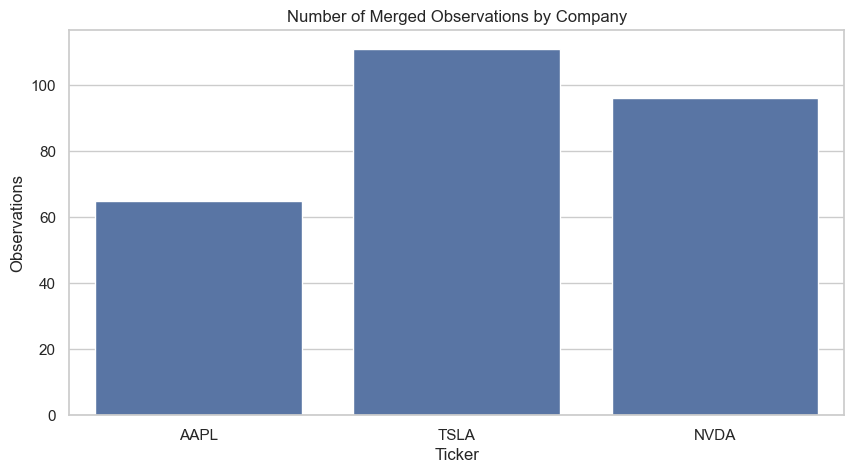

In [570]:
plt.figure(figsize=(10, 5))
sns.countplot(data=model_df, x="Ticker", order=selected_tickers)
plt.title("Number of Merged Observations by Company")
plt.xlabel("Ticker")
plt.ylabel("Observations")
plt.show()

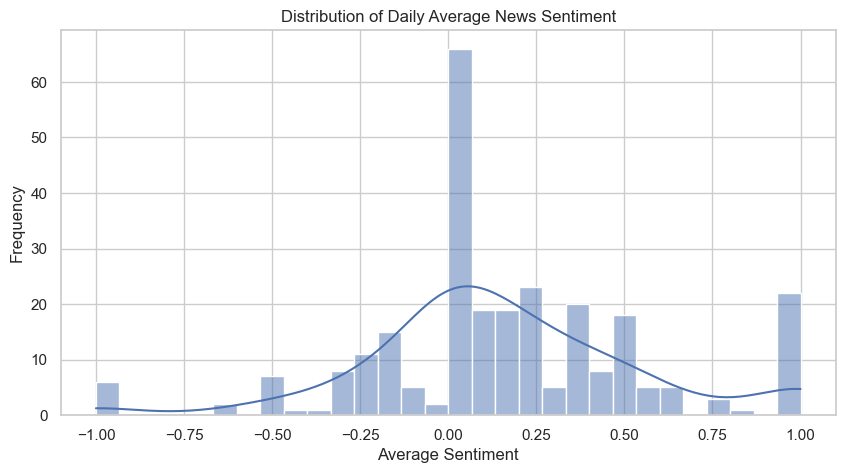

In [571]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["avg_sentiment"], bins=30, kde=True)
plt.title("Distribution of Daily Average News Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")
plt.show()

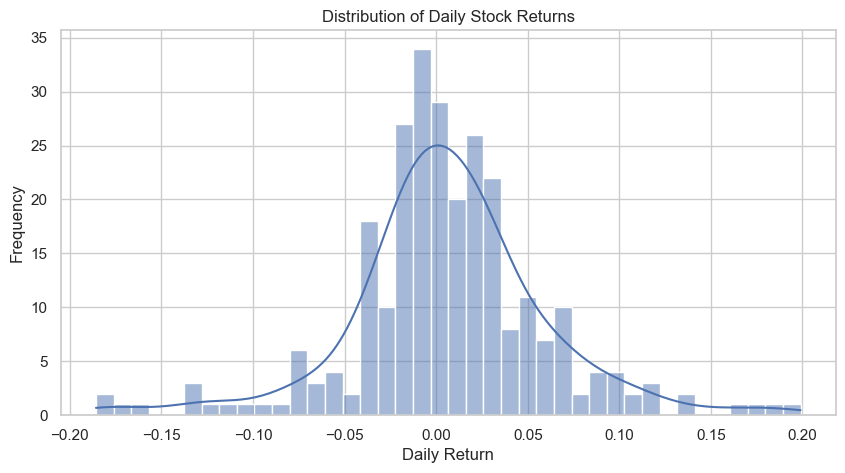

In [572]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["Daily Return"].dropna(), bins=40, kde=True)
plt.title("Distribution of Daily Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

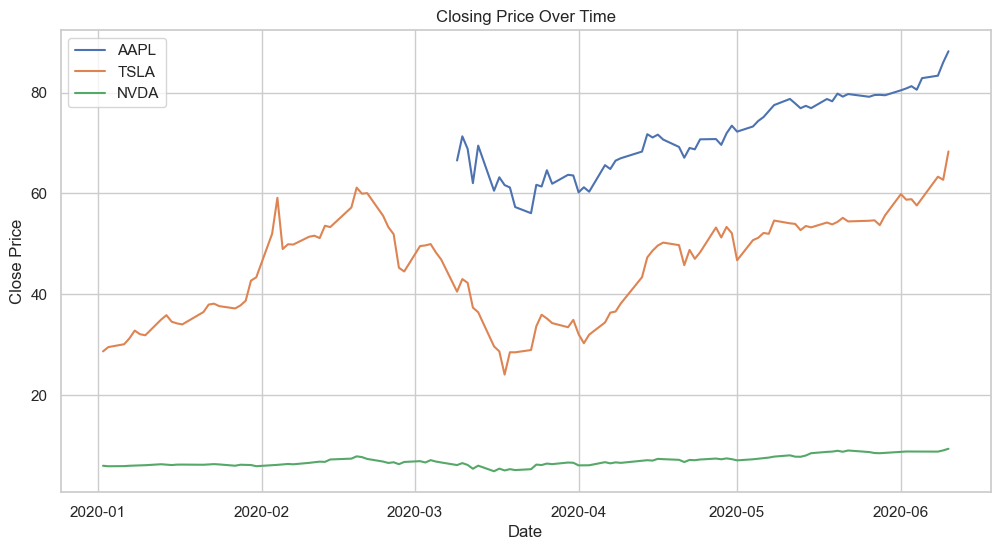

In [573]:
plt.figure(figsize=(12, 6))
for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker]
    plt.plot(subset["Date"], subset["Close"], label=ticker)

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

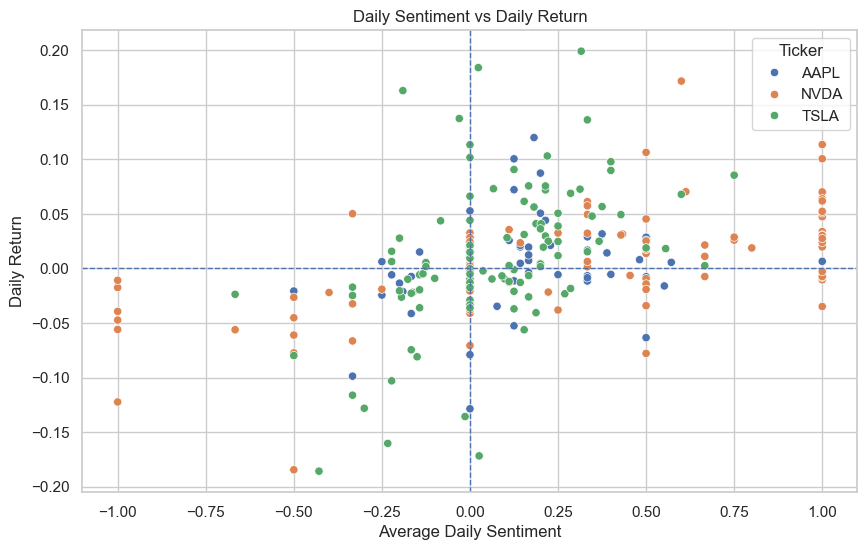

In [574]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=model_df,
    x="avg_sentiment",
    y="Daily Return",
    hue="Ticker"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Daily Sentiment vs Daily Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return")
plt.show()

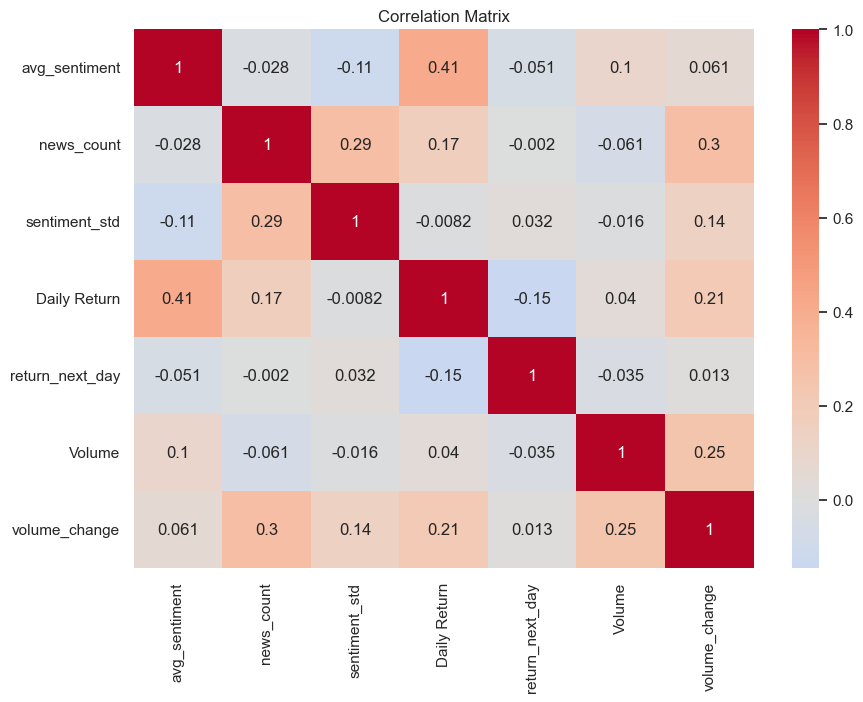

In [575]:
corr_columns = ["avg_sentiment", "news_count", "sentiment_std", "Daily Return", "return_next_day", "Volume", "volume_change"]
corr_columns = [column for column in corr_columns if column in model_df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(model_df[corr_columns].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 9. Hypothesis testing

### Hypothesis 1: correlation between sentiment and same-day returns

- $H_0$: There is no linear relationship between daily sentiment and same-day returns.
- $H_1$: There is a linear relationship between daily sentiment and same-day returns.

### Hypothesis 2: correlation between sentiment and next-day returns

- $H_0$: There is no linear relationship between daily sentiment and next-day returns.
- $H_1$: There is a linear relationship between daily sentiment and next-day returns.

In [576]:
def correlation_test(data, x_col, y_col):
    clean = data[[x_col, y_col]].dropna()
    if len(clean) < 3:
        return {
            "n": len(clean),
            "pearson_r": np.nan,
            "p_value": np.nan
        }

    r, p = stats.pearsonr(clean[x_col], clean[y_col])
    return {
        "n": len(clean),
        "pearson_r": r,
        "p_value": p
    }

results = []

for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker]

    same_day = correlation_test(subset, "avg_sentiment", "Daily Return")
    same_day["Ticker"] = ticker
    same_day["Target"] = "Same-day return"
    results.append(same_day)

    next_day = correlation_test(subset, "avg_sentiment", "return_next_day")
    next_day["Ticker"] = ticker
    next_day["Target"] = "Next-day return"
    results.append(next_day)

correlation_results = pd.DataFrame(results)
display(correlation_results)

,n,pearson_r,p_value,Ticker,Target
0,65,0.232177,6.273382e-02,AAPL,Same-day return
1,65,-0.193176,1.231274e-01,AAPL,Next-day return
2,110,0.469142,2.345164e-07,TSLA,Same-day return
3,111,0.090269,3.460909e-01,TSLA,Next-day return
4,95,0.579136,7.837871e-10,NVDA,Same-day return
5,96,-0.104333,3.117190e-01,NVDA,Next-day return


### T-test: positive-sentiment days vs negative-sentiment days

I also compare the average returns on positive-sentiment days and negative-sentiment days.

- $H_0$: The mean returns are the same for the two groups.
- $H_1$: The mean returns are different for the two groups.


In [577]:
ttest_results = []

for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker].dropna(subset=["Daily Return", "avg_sentiment"])

    positive_returns = subset[subset["avg_sentiment"] > 0]["Daily Return"]
    negative_returns = subset[subset["avg_sentiment"] < 0]["Daily Return"]

    if len(positive_returns) >= 2 and len(negative_returns) >= 2:
        t_stat, p_value = stats.ttest_ind(
            positive_returns,
            negative_returns,
            equal_var=False
        )
    else:
        t_stat, p_value = np.nan, np.nan

    ttest_results.append({
        "Ticker": ticker,
        "Positive sentiment days": len(positive_returns),
        "Negative sentiment days": len(negative_returns),
        "Mean return positive": positive_returns.mean() if len(positive_returns) else np.nan,
        "Mean return negative": negative_returns.mean() if len(negative_returns) else np.nan,
        "t_statistic": t_stat,
        "p_value": p_value
    })

ttest_results_df = pd.DataFrame(ttest_results)
display(ttest_results_df)

,Ticker,Positive sentiment days,Negative sentiment days,Mean return positive,Mean return negative,t_statistic,p_value
0,AAPL,38,10,0.015285,-0.021242,3.149615,0.006236
1,TSLA,57,31,0.031073,-0.029129,3.922159,0.000269
2,NVDA,56,17,0.025382,-0.049107,5.591744,0.000011


## 10. Prediction models

The target variable is **next-day daily return**.

I use next-day return because the practical question is whether today's information can help predict the next trading day, not whether it explains the same day after the fact.

### Train/test split

Since financial data is ordered in time, I avoid a random split. A random split could put later market conditions into the training set and make the result look better than it really is.

Instead, I use a chronological split:

- first 75% of observations by date for training,
- last 25% for testing.

This is closer to a real forecasting situation.

### Models

I compare three simple models:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

### Metrics

The models are compared using:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y_i})^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y_i}|
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$


In [578]:
model_data = model_df.dropna(subset=["return_next_day", "avg_sentiment", "news_count", "Daily Return", "Volume"]).copy()
model_data = model_data.sort_values(["Date", "Ticker"]).reset_index(drop=True)

model_data["Ticker_encoded"] = model_data["Ticker"].astype("category").cat.codes

feature_columns = [
    "avg_sentiment",
    "news_count",
    "sentiment_std",
    "Daily Return",
    "Volume",
    "volume_change",
    "Ticker_encoded"
]

feature_columns = [column for column in feature_columns if column in model_data.columns]

model_data = model_data.replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna(subset=feature_columns + ["return_next_day"])

X = model_data[feature_columns]
y = model_data["return_next_day"]

print("Modeling dataset shape:", model_data.shape)
print("Features:", feature_columns)
display(model_data.head())


Modeling dataset shape: (270, 15)
Features: ['avg_sentiment', 'news_count', 'sentiment_std', 'Daily Return', 'Volume', 'volume_change', 'Ticker_encoded']


,Ticker,Date,Open,High,Low,Close,Volume,Daily Return,return_next_day,avg_sentiment,news_count,sentiment_std,20-Day MA,volume_change,Ticker_encoded
0,NVDA,2020-01-03,5.877500,5.945750,5.852500,5.901750,205384000,-0.016006,0.004194,0.000000,1,0.000000,NaN,-0.135356,1
1,TSLA,2020-01-03,29.366667,30.266666,29.128000,29.534000,266677500,0.029633,0.019255,0.214286,14,0.699293,NaN,0.865119,2
2,NVDA,2020-01-06,5.808000,5.931750,5.781750,5.926500,262636000,0.004194,0.012107,0.000000,1,0.000000,NaN,0.278756,1
3,TSLA,2020-01-06,29.364668,30.104000,29.333332,30.102667,151995000,0.019255,0.038801,0.000000,7,0.577350,NaN,-0.430042,2
4,NVDA,2020-01-07,5.955000,6.044250,5.909750,5.998250,314856000,0.012107,0.001876,0.000000,1,0.000000,NaN,0.198830,1


In [579]:
if len(model_data) >= 30:
    split_index = int(len(model_data) * 0.75)

    train_data = model_data.iloc[:split_index].copy()
    test_data = model_data.iloc[split_index:].copy()

    X_train = train_data[feature_columns]
    y_train = train_data["return_next_day"]
    X_test = test_data[feature_columns]
    y_test = test_data["return_next_day"]

    print("Training period:", train_data["Date"].min(), "to", train_data["Date"].max())
    print("Testing period:", test_data["Date"].min(), "to", test_data["Date"].max())
    print("Training observations:", len(train_data))
    print("Testing observations:", len(test_data))

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree Regression": DecisionTreeRegressor(
            random_state=42,
            max_depth=4,
            min_samples_leaf=5
        ),
        "Random Forest Regression": RandomForestRegressor(
            random_state=42,
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=5
        )
    }

    evaluation_results = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        mse = mean_squared_error(y_test, predictions)
        rmse = math.sqrt(mse)
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        evaluation_results.append({
            "Model": model_name,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    evaluation_df = pd.DataFrame(evaluation_results).sort_values("RMSE").reset_index(drop=True)
    display(evaluation_df)
else:
    print("Not enough merged observations for reliable modeling.")


Training period: 2020-01-03 00:00:00 to 2020-05-05 00:00:00
Testing period: 2020-05-06 00:00:00 to 2020-06-10 00:00:00
Training observations: 202
Testing observations: 68


,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.000763,0.027619,0.021360,-0.001837
1,Random Forest Regression,0.000863,0.029380,0.022958,-0.133643
2,Decision Tree Regression,0.001270,0.035640,0.027496,-0.668180


Best model by RMSE: Linear Regression


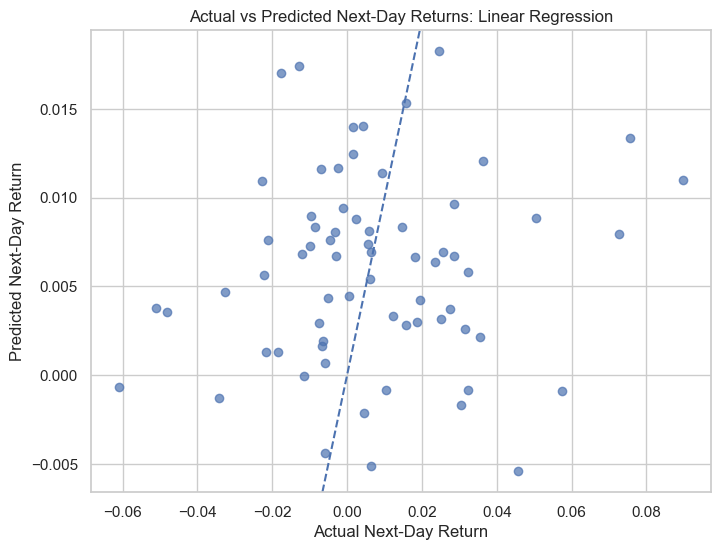

In [580]:
if len(model_data) >= 30:
    best_model_name = evaluation_df.iloc[0]["Model"]
    print("Best model by RMSE:", best_model_name)

    best_model = models[best_model_name]
    predictions = best_model.predict(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, predictions, alpha=0.7)
    plt.axline((0, 0), slope=1, linestyle="--")
    plt.title(f"Actual vs Predicted Next-Day Returns: {best_model_name}")
    plt.xlabel("Actual Next-Day Return")
    plt.ylabel("Predicted Next-Day Return")
    plt.show()

,Feature,Importance
3,Daily Return,0.389199
5,volume_change,0.237617
4,Volume,0.137396
0,avg_sentiment,0.092133
2,sentiment_std,0.063689
1,news_count,0.051697
6,Ticker_encoded,0.028270


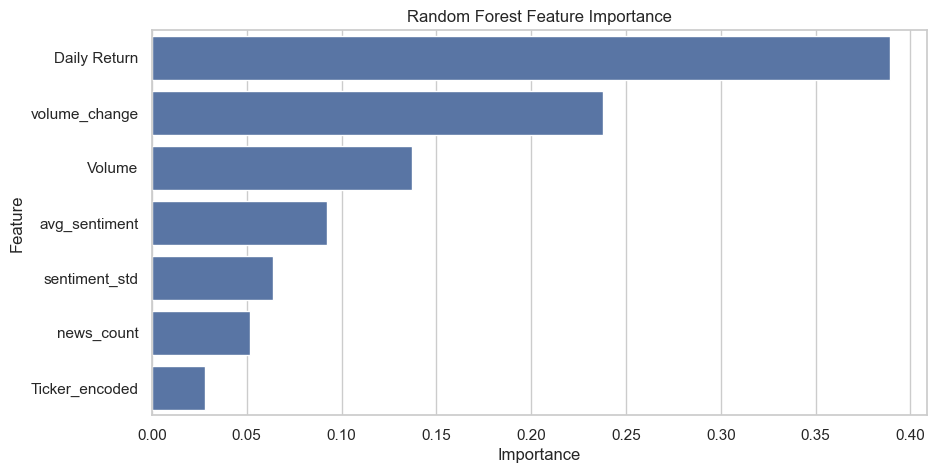

In [581]:
if len(model_data) >= 30 and hasattr(models["Random Forest Regression"], "feature_importances_"):
    rf_model = models["Random Forest Regression"]
    importances = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": rf_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importances)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=importances, x="Importance", y="Feature")
    plt.title("Random Forest Feature Importance")
    plt.show()

## 11. Lagged sentiment check

A stronger causality-focused study would need more econometric testing, for example stationarity checks, lag selection, backtesting, and clearer assumptions about timing.

As a smaller extension, I create 1-day, 2-day, and 3-day lagged sentiment features. This checks whether sentiment from previous days has more predictive value than same-day sentiment. The split is still chronological, so later observations are not used to train the model.


In [582]:
lagged_df = model_df.sort_values(["Ticker", "Date"]).copy()

for lag in [1, 2, 3]:
    lagged_df[f"sentiment_lag_{lag}"] = lagged_df.groupby("Ticker")["avg_sentiment"].shift(lag)

lag_feature_columns = [
    "avg_sentiment",
    "sentiment_lag_1",
    "sentiment_lag_2",
    "sentiment_lag_3",
    "news_count",
    "Daily Return"
]

lag_model_data = lagged_df.dropna(subset=lag_feature_columns + ["return_next_day"]).copy()
lag_model_data = lag_model_data.sort_values(["Date", "Ticker"]).reset_index(drop=True)

if len(lag_model_data) >= 30:
    lag_split_index = int(len(lag_model_data) * 0.75)

    lag_train = lag_model_data.iloc[:lag_split_index].copy()
    lag_test = lag_model_data.iloc[lag_split_index:].copy()

    X_train_lag = lag_train[lag_feature_columns]
    y_train_lag = lag_train["return_next_day"]
    X_test_lag = lag_test[lag_feature_columns]
    y_test_lag = lag_test["return_next_day"]

    lag_model = LinearRegression()
    lag_model.fit(X_train_lag, y_train_lag)
    lag_predictions = lag_model.predict(X_test_lag)

    lag_results = {
        "MSE": mean_squared_error(y_test_lag, lag_predictions),
        "RMSE": math.sqrt(mean_squared_error(y_test_lag, lag_predictions)),
        "MAE": mean_absolute_error(y_test_lag, lag_predictions),
        "R2": r2_score(y_test_lag, lag_predictions)
    }

    print("Lagged sentiment linear model results:")
    display(pd.DataFrame([lag_results]))

    coefficients = pd.DataFrame({
        "Feature": lag_feature_columns,
        "Coefficient": lag_model.coef_
    }).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)
    display(coefficients)
else:
    print("Not enough data for lagged sentiment modeling.")


Lagged sentiment linear model results:


,MSE,RMSE,MAE,R2
0,0.00085,0.029163,0.021589,-0.086559


,Feature,Coefficient
5,Daily Return,-0.150163
2,sentiment_lag_2,0.016842
1,sentiment_lag_1,0.016572
3,sentiment_lag_3,-0.004170
4,news_count,0.000432
0,avg_sentiment,-0.000333


## 12. Final interpretation

This notebook should be read as an empirical check, not as proof that news sentiment causes stock-price movements.

### Data coverage

The final dataset only includes dates where both news and stock data are available for the same company. This makes the dataset cleaner, but it also reduces the number of observations. The coverage table helps show which companies have the best overlap between the two sources.

### Sentiment and returns

The correlation and t-test sections show whether sentiment is statistically related to same-day or next-day returns. A significant result would mean that the variables move together in the sample, but it would not prove causality. A weak result is also useful, because short-term stock returns are noisy and can be affected by many factors that are not captured in headlines.

### Model performance

The prediction models use sentiment features, article count, recent return, volume, and company identity to predict next-day returns. The chronological split makes the test more realistic than a random split.

If the Random Forest performs better than the simpler models, that may suggest some nonlinear patterns. However, feature importance should still be interpreted carefully. If `Daily Return` or `Volume` is more important than sentiment, then the main conclusion is that recent market behavior explains more variation than this simple sentiment score.

### Limitations

1. The sentiment method is dictionary-based, so it may miss context, negation, sarcasm, or more subtle financial language.
2. The analysis uses daily aggregation, so the exact time of the headline is lost. News after market close may affect the next day instead of the same day.
3. Only three technology companies are included, so the result may not generalize to the whole market.
4. Correlation and regression do not prove causality.
5. The merged dataset only includes dates with both news and price data.


In [583]:
print("Final coverage summary")
display(coverage_summary)

if "correlation_results" in globals():
    print("Correlation test summary")
    display(correlation_results)

if "ttest_results_df" in globals():
    print("T-test summary")
    display(ttest_results_df)

if "evaluation_df" in globals():
    print("Model evaluation summary")
    display(evaluation_df)
    best_model_name = evaluation_df.iloc[0]["Model"]
    best_rmse = evaluation_df.iloc[0]["RMSE"]
    best_r2 = evaluation_df.iloc[0]["R2"]
    print(f"Best model by RMSE: {best_model_name}")
    print(f"Best RMSE: {best_rmse:.6f}")
    print(f"Best R2: {best_r2:.6f}")


Final coverage summary


,Ticker,first_date,last_date,observations,mean_sentiment,mean_daily_return,mean_next_day_return
0,AAPL,2020-03-09,2020-06-10,65,0.140065,0.003693,0.004006
1,NVDA,2020-01-02,2020-06-10,96,0.270139,0.004237,0.004185
2,TSLA,2020-01-02,2020-06-10,111,0.067746,0.010009,0.009460


Correlation test summary


,n,pearson_r,p_value,Ticker,Target
0,65,0.232177,6.273382e-02,AAPL,Same-day return
1,65,-0.193176,1.231274e-01,AAPL,Next-day return
2,110,0.469142,2.345164e-07,TSLA,Same-day return
3,111,0.090269,3.460909e-01,TSLA,Next-day return
4,95,0.579136,7.837871e-10,NVDA,Same-day return
5,96,-0.104333,3.117190e-01,NVDA,Next-day return


T-test summary


,Ticker,Positive sentiment days,Negative sentiment days,Mean return positive,Mean return negative,t_statistic,p_value
0,AAPL,38,10,0.015285,-0.021242,3.149615,0.006236
1,TSLA,57,31,0.031073,-0.029129,3.922159,0.000269
2,NVDA,56,17,0.025382,-0.049107,5.591744,0.000011


Model evaluation summary


,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.000763,0.027619,0.021360,-0.001837
1,Random Forest Regression,0.000863,0.029380,0.022958,-0.133643
2,Decision Tree Regression,0.001270,0.035640,0.027496,-0.668180


Best model by RMSE: Linear Regression
Best RMSE: 0.027619
Best R2: -0.001837


## 13. Conclusion

This project combines financial news headlines with stock-price data and turns the headlines into daily sentiment features. The main goal is to test whether these sentiment features have any relationship with short-term returns.

The notebook covers:

- combining two datasets,
- cleaning and checking the data,
- preparing text for sentiment scoring,
- calculating daily returns,
- merging sentiment with stock prices,
- exploratory analysis,
- hypothesis testing,
- basic regression modeling,
- chronological train/test evaluation.

Overall, the project gives a structured but realistic baseline. The sentiment score is simple, so the results should be interpreted carefully rather than treated as a trading signal.


## References

### Data sources

- Dataset 1: https://www.kaggle.com/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests/data
- Dataset 2: https://www.kaggle.com/datasets/sandiledesmondmfazi/tech-stock-financial-dataset

- Linl to google-drive : https://drive.google.com/file/d/1KK9gBuhmQWNsez2LmPQcXsKerP6D81MW/view?usp=sharing

- Uploaded dataset: `analyst_ratings_processed.csv`
- Uploaded dataset: `tech_stock_prices_2020_to_today.csv`

### Python libraries and documentation

- pandas documentation: https://pandas.pydata.org/docs/
- NumPy documentation: https://numpy.org/doc/
- Matplotlib documentation: https://matplotlib.org/stable/index.html
- seaborn documentation: https://seaborn.pydata.org/
- SciPy statistics documentation: https://docs.scipy.org/doc/scipy/reference/stats.html
- scikit-learn documentation: https://scikit-learn.org/stable/user_guide.html

### Statistical and financial concepts

- Pearson correlation coefficient: https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
- Welch's t-test: https://en.wikipedia.org/wiki/Welch%27s_t-test
- Coefficient of determination $R^2$: https://en.wikipedia.org/wiki/Coefficient_of_determination
- Event study methodology: https://en.wikipedia.org/wiki/Event_study
- Efficient-market hypothesis: https://en.wikipedia.org/wiki/Efficient-market_hypothesis
